# Detectability score

### Combine all score from Copyleaks, Sapling, Zerogpt.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../datasets.csv')
df.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...


In [4]:
df.shape

(180, 6)

# Copyleaks
- use the first number, i.e. AI Content Found (Percentage of text that may be AI-generated)
- the second number of AI phrases detected.

In [5]:
df_copyleaks = df.copy()
df_copyleaks['AI_detectability'] = 100
df_copyleaks['humanized_detectability'] = 0
df_copyleaks.head(6)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_detectability,humanized_detectability
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100,0
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,100,0
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,100,0
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,100,0
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,100,0
5,1,1,gemini2.5pro,writehuman.ai,The integration of social media into the lives...,There is an important and critical psychologic...,100,0


In [8]:
df_copyleaks.sort_values(by=['humanizer','topic','length'], inplace=True, ignore_index=True)
df_copyleaks.head(6)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_detectability,humanized_detectability
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100,0
1,1,1,gpt4.0,AIHumanizer,Social media has undeniably transformed the wa...,Social media has really changed how young peop...,100,0
2,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...,100,0
3,1,2,gpt4.0,AIHumanizer,"In the digital age, social media has become an...","In today’s digital world, social media has rea...",100,0
4,1,3,gpt4.0,AIHumanizer,"In recent years, social media has revolutioniz...","Over the past few years, social media has comp...",100,0
5,1,3,gemini2.5pro,AIHumanizer,The integration of social media into the daily...,Social media has become such a regular part of...,100,0


In [9]:
#AIHumanizer
#set first 30 rows of 'humanized_detectability' to 100
df_copyleaks.loc[0:29, 'humanized_detectability'] = 100

In [10]:
#Grammarly
#set rows 30-59 of 'humanized_detectability' to 100
df_copyleaks.loc[30:59, 'humanized_detectability'] = 100

In [13]:
#HumanizeAI
HumanizeAI = [100, 0, 0, 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 64.4, 100, 100, 100, 100, 73.1, 100, 100, 100, 0, 100, 100, 45.2]
#set rows 60-89 of 'humanized_detectability' to HumanizeAI list
df_copyleaks.loc[60:89, 'humanized_detectability'] = HumanizeAI

In [15]:
#Quillbot
Quillbot = [100, 100, 80.3, 100, 100, 100, 100, 100, 0, 100, 0, 100 ,100 ,100 ,100 ,100 ,100 ,100, 0, 100,100, 100, 100, 100, 100, 100, 100, 100 ,100, 100]
#set rows 90-119 of 'humanized_detectability' to Quillbot list
df_copyleaks.loc[90:119, 'humanized_detectability'] = Quillbot

In [16]:
#UndetectableAI
UndetectableAI = [0, 0, 0, 0, 0, 0, 0, 0 ,0, 0, 0, 100, 100, 0, 0, 100, 0, 100, 0, 100, 100, 0, 0, 100, 100 ,100, 100, 100, 0, 100]
#set rows 120-149 of 'humanized_detectability' to UndetectableAI list
df_copyleaks.loc[120:149, 'humanized_detectability'] = UndetectableAI

In [17]:
#writehuman.ai
writehumanai = [0, 0, 62, 100, 0, 0, 0, 0, 0, 0, 0, 24.4, 0, 0, 0, 0, 0, 66.6, 0, 0, 78.8, 0, 0, 0, 0, 100, 0, 0, 100, 100]
#set rows 150-179 of 'humanized_detectability' to writehumanai list
df_copyleaks.loc[150:179, 'humanized_detectability'] = writehumanai
# set rows 176 of 'humanized_detectability' to NA
df_copyleaks.loc[176, 'humanized_detectability'] = None

# Zerogpt
- use fakePercentage

In [29]:
zerogpt = pd.read_csv("zerogpt_results.csv")
print(zerogpt.shape)
zerogpt.head()

(210, 7)


,filepath,filename,fakePercentage,isHuman,feedback,aiWords,textWords
0,../datasets/essays/TOPIC3_2_GPT4.0.txt,TOPIC3_2_GPT4.0.txt,100.0,0.0,Your Text is AI/GPT Generated,593,593
1,../datasets/essays/TOPIC4_2_GPT4.0.txt,TOPIC4_2_GPT4.0.txt,100.0,0.0,Your Text is AI/GPT Generated,450,450
2,../datasets/essays/TOPIC1_1_GPT4.0.txt,TOPIC1_1_GPT4.0.txt,100.0,0.0,Your Text is AI/GPT Generated,258,258
3,../datasets/essays/TOPIC5_3_GEMINI2.5PRO.txt,TOPIC5_3_GEMINI2.5PRO.txt,100.0,0.0,Your Text is AI/GPT Generated,882,882
4,../datasets/essays/TOPIC2_1_GEMINI2.5PRO.txt,TOPIC2_1_GEMINI2.5PRO.txt,100.0,0.0,Your Text is AI/GPT Generated,276,276


In [30]:
zerogpt['type'] = None
zerogpt['topic'] = None
zerogpt['length'] = None
zerogpt['AI_model'] = None
for i, row in zerogpt.iterrows():
    type = row['filepath'].split('/')
    if len(type) == 4:
        zerogpt.at[i, 'type'] = 'AI'
    else:
        zerogpt.at[i, 'type'] = type[3]
    topic, length, model = row['filename'].split('_')
    topic = int(topic[5])
    length = int(length)
    model = model[:-4].lower()
    zerogpt.at[i, 'topic'] = topic
    zerogpt.at[i, 'length'] = length
    zerogpt.at[i, 'AI_model'] = model
zerogpt.sort_values(by=['type','topic','length', 'AI_model'], inplace=True, ignore_index=True)
zerogpt.head()

,filepath,filename,fakePercentage,isHuman,feedback,aiWords,textWords,type,topic,length,AI_model
0,../datasets/essays/TOPIC1_1_GEMINI2.5PRO.txt,TOPIC1_1_GEMINI2.5PRO.txt,100.00,0.0,Your Text is AI/GPT Generated,266,266,AI,1,1,gemini2.5pro
1,../datasets/essays/TOPIC1_1_GPT4.0.txt,TOPIC1_1_GPT4.0.txt,100.00,0.0,Your Text is AI/GPT Generated,258,258,AI,1,1,gpt4.0
2,../datasets/essays/TOPIC1_2_GEMINI2.5PRO.txt,TOPIC1_2_GEMINI2.5PRO.txt,79.21,12.5,Most of Your Text is AI/GPT Generated,476,578,AI,1,2,gemini2.5pro
3,../datasets/essays/TOPIC1_2_GPT4.0.txt,TOPIC1_2_GPT4.0.txt,100.00,0.0,Your Text is AI/GPT Generated,517,517,AI,1,2,gpt4.0
4,../datasets/essays/TOPIC1_3_GEMINI2.5PRO.txt,TOPIC1_3_GEMINI2.5PRO.txt,72.07,12.5,Most of Your Text is AI/GPT Generated,763,988,AI,1,3,gemini2.5pro


In [37]:
detect_score = zerogpt['fakePercentage'].tolist()
ai_score = detect_score[:30]
ai_score = ai_score*6
len(ai_score)

180

In [38]:
humanized_score = detect_score[30:]
len(humanized_score)

180

In [ ]:
df_zerogpt = df.copy()
df_zerogpt.sort_values(by=['humanizer','topic','length'], inplace=True, ignore_index=True)
df_zerogpt['AI_detectability'] = ai_score
df_zerogpt['humanized_detectability'] = humanized_score
df_zerogpt.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_detectability,humanized_detectability
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100.00,100.00
1,1,1,gpt4.0,AIHumanizer,Social media has undeniably transformed the wa...,Social media has really changed how young peop...,100.00,100.00
2,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...,79.21,100.00
3,1,2,gpt4.0,AIHumanizer,"In the digital age, social media has become an...","In today’s digital world, social media has rea...",100.00,100.00
4,1,3,gemini2.5pro,AIHumanizer,The integration of social media into the daily...,Social media has become such a regular part of...,72.07,92.24


# Sapling
- use 'score' column

In [75]:
sapling = pd.read_csv('sapling_results.csv')
print(sapling.shape)
sapling.head()

(210, 6)


,filepath,filename,score,sentence_score,token_probs,token
0,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC3_2_GPT4.0.txt,0.999960,"[{""score"": 0.9931961718574452, ""sentence"": ""J....","[0.9999520873934671, 0.9999339143323596, 0.999...","[""J"", ""."", ""K"", ""."", "" Rowling"", ""\u2019"", ""s""..."
1,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC4_2_GPT4.0.txt,0.996421,"[{""score"": 0.04109587792356928, ""sentence"": ""A...","[0.9999875543207963, 0.9999881878793531, 0.999...","[""As"", "" artificial"", "" intelligence"", "" ("", ""..."
2,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_1_GPT4.0.txt,0.999856,"[{""score"": 0.9970659579067691, ""sentence"": ""So...","[0.9999877169693718, 0.9999878612616158, 0.999...","[""Social"", "" media"", "" has"", "" undeniably"", "" ..."
3,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC5_3_GEMINI2.5PRO.txt,0.999942,"[{""score"": 3.702376560887899e-08, ""sentence"": ...","[0.9999844959274924, 0.9999861980550122, 0.999...","[""The"", "" landscape"", "" of"", "" childhood"", "" i..."
4,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC2_1_GEMINI2.5PRO.txt,0.999974,"[{""score"": 0.00016756883622148777, ""sentence"":...","[0.9999881489402469, 0.9999884189392105, 0.999...","[""A"", "" silent"", "","", "" stationary"", "" fan"", ""..."


In [76]:
humanizers = ['AIHumanizer', 'Grammarly', 'HumanizeAI', 'Quillbot', 'UndetectableAI', 'writehuman.ai']
sapling['type'] = None
sapling['topic'] = None
sapling['length'] = None
sapling['AI_model'] = None
for i, row in sapling.iterrows():
    type = row['filepath'].split('/')
    isai = True
    for humanizer in humanizers:
        if humanizer in type:
            sapling.at[i, 'type'] = humanizer
            isai = False
            break
    if isai:
        sapling.at[i, 'type'] = 'AI'
    topic, length, model = row['filename'].split('_')
    topic = int(topic[5])
    length = int(length)
    model = model[:-4].lower()
    sapling.at[i, 'topic'] = topic
    sapling.at[i, 'length'] = length
    sapling.at[i, 'AI_model'] = model
sapling.sort_values(by=['type','topic','length', 'AI_model'], inplace=True, ignore_index=True)
sapling.head()

,filepath,filename,score,sentence_score,token_probs,token,type,topic,length,AI_model
0,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_1_GEMINI2.5PRO.txt,0.999977,"[{""score"": 0.1356348630967481, ""sentence"": ""Th...","[0.9999855877567825, 0.9999863500279389, 0.999...","[""The"", "" integration"", "" of"", "" social"", "" me...",AI,1,1,gemini2.5pro
1,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_1_GPT4.0.txt,0.999856,"[{""score"": 0.9970659579067691, ""sentence"": ""So...","[0.9999877169693718, 0.9999878612616158, 0.999...","[""Social"", "" media"", "" has"", "" undeniably"", "" ...",AI,1,1,gpt4.0
2,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_2_GEMINI2.5PRO.txt,0.999803,"[{""score"": 0.9912204637289971, ""sentence"": ""Th...","[0.9999881291587371, 0.9999884908911554, 0.999...","[""The"", "" pervasive"", "" integration"", "" of"", ""...",AI,1,2,gemini2.5pro
3,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_2_GPT4.0.txt,0.999874,"[{""score"": 0.9995484959432652, ""sentence"": ""In...","[0.9999889039127083, 0.999989114168784, 0.9999...","[""In"", "" the"", "" digital"", "" age"", "","", "" soci...",AI,1,2,gpt4.0
4,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_3_GEMINI2.5PRO.txt,0.795353,"[{""score"": 0.9955431358518562, ""sentence"": ""Th...","[0.9999795212552272, 0.9999799321012688, 0.999...","[""The"", "" integration"", "" of"", "" social"", "" me...",AI,1,3,gemini2.5pro


In [77]:
detect_score = sapling['score'].tolist()
ai_score = detect_score[:30]
ai_score = [i*100 for i in ai_score]
ai_score = ai_score*6
len(ai_score)

180

In [78]:
humanized_score = detect_score[30:]
humanized_score = [i*100 for i in humanized_score]

In [79]:
df_sapling = df.copy()
df_sapling.sort_values(by=['humanizer','topic','length'], inplace=True, ignore_index=True)
df_sapling['AI_detectability'] = ai_score
df_sapling['humanized_detectability'] = humanized_score
df_sapling.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_detectability,humanized_detectability
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,99.997658,99.995351
1,1,1,gpt4.0,AIHumanizer,Social media has undeniably transformed the wa...,Social media has really changed how young peop...,99.985579,99.961515
2,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...,99.980250,98.531897
3,1,2,gpt4.0,AIHumanizer,"In the digital age, social media has become an...","In today’s digital world, social media has rea...",99.987373,99.995690
4,1,3,gemini2.5pro,AIHumanizer,The integration of social media into the daily...,Social media has become such a regular part of...,79.535308,99.990372


# Combine all three dataframes

In [80]:
df_merged = df_copyleaks.merge(df_zerogpt, on=['humanizer', 'topic', 'length', 'AI_model', 'AI_essay', 'humanized_essay'], suffixes=('_copyleaks', '_zerogpt'))
df_merged = df_merged.merge(df_sapling, on=['humanizer', 'topic', 'length', 'AI_model', 'AI_essay', 'humanized_essay'])
df_merged.rename(columns={'AI_detectability': 'sapling_AI', 'humanized_detectability': 'sapling_humanized', 'AI_detectability_copyleaks': 'copyleaks_AI', 'humanized_detectability_copyleaks': 'copyleaks_humanized', 'AI_detectability_zerogpt': 'zerogpt_AI', 'humanized_detectability_zerogpt': 'zerogpt_humanized'}, inplace=True)
df_merged.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100,100.0,100.00,100.0,99.997658,99.995351
1,1,1,gpt4.0,AIHumanizer,Social media has undeniably transformed the wa...,Social media has really changed how young peop...,100,100.0,100.00,100.0,99.985579,99.961515
2,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...,100,100.0,79.21,100.0,99.980250,98.531897
3,1,2,gpt4.0,AIHumanizer,"In the digital age, social media has become an...","In today’s digital world, social media has rea...",100,100.0,100.00,100.0,99.987373,99.995690
4,1,3,gpt4.0,AIHumanizer,"In recent years, social media has revolutioniz...","Over the past few years, social media has comp...",100,100.0,99.99,100.0,99.990441,99.935826


In [81]:
# convert detectability columns to float
df_merged['copyleaks_AI'] = df_merged['copyleaks_AI'].astype('float64')
df_merged['copyleaks_humanized'] = df_merged['copyleaks_humanized'].astype('float64')
df_merged['zerogpt_AI'] = df_merged['zerogpt_AI'].astype('float64')
df_merged['zerogpt_humanized'] = df_merged['zerogpt_humanized'].astype('float64')
df_merged['sapling_AI'] = df_merged['sapling_AI'].astype('float64')
df_merged['sapling_humanized'] = df_merged['sapling_humanized'].astype('float64')

In [87]:
df_merged_temp = df_merged.drop(columns=['AI_essay', 'humanized_essay'])
df_merged_temp.to_csv('detection_results.csv', index=False)

# Analysis

#### mean of each humanizer and detectors (overall, by length, by AI model)

In [83]:
# group by humanizers and find mean of each detectability column
df_humanizer = df_merged.groupby('humanizer').mean(numeric_only=True)
# drop topic and length columns
df_humanizer = df_humanizer.drop(columns=['topic', 'length'])
df_humanizer.reset_index(inplace=True)
df_humanizer

,humanizer,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,AIHumanizer,100.0,100.000000,98.175,99.390333,99.25927,99.917411
1,Grammarly,100.0,100.000000,98.175,98.736667,99.25927,99.625696
2,HumanizeAI,100.0,42.756667,98.175,23.680333,99.25927,70.250907
3,Quillbot,100.0,89.343333,98.175,84.378667,99.25927,91.023671
4,UndetectableAI,100.0,40.000000,98.175,13.993333,99.25927,90.175996
5,writehuman.ai,100.0,21.786207,98.175,32.848667,99.25927,83.910862


In [84]:
df_ai_humanizer = df_merged.groupby(['AI_model', 'humanizer']).mean(numeric_only=True)
df_ai_humanizer = df_ai_humanizer.drop(columns=['topic', 'length'])
df_ai_humanizer.reset_index(inplace=True)
df_ai_humanizer

,AI_model,humanizer,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,gemini2.5pro,AIHumanizer,100.0,100.000000,96.495333,99.107333,98.559336,99.854567
1,gemini2.5pro,Grammarly,100.0,100.000000,96.495333,97.774667,98.559336,99.931092
2,gemini2.5pro,HumanizeAI,100.0,38.206667,96.495333,18.714667,98.559336,59.867368
3,gemini2.5pro,Quillbot,100.0,92.020000,96.495333,74.595333,98.559336,84.440737
4,gemini2.5pro,UndetectableAI,100.0,33.333333,96.495333,13.644667,98.559336,85.913429
5,gemini2.5pro,writehuman.ai,100.0,24.671429,96.495333,24.774000,98.559336,80.007925
6,gpt4.0,AIHumanizer,100.0,100.000000,99.854667,99.673333,99.959203,99.980255
7,gpt4.0,Grammarly,100.0,100.000000,99.854667,99.698667,99.959203,99.320300
8,gpt4.0,HumanizeAI,100.0,47.306667,99.854667,28.646000,99.959203,80.634447
9,gpt4.0,Quillbot,100.0,86.666667,99.854667,94.162000,99.959203,97.606606


# Visualization

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

In [92]:
df = pd.read_csv('detection_results.csv')

# Melt the dataframe to make it suitable for Seaborn plotting
humanized_cols = ['copyleaks_humanized', 'zerogpt_humanized', 'sapling_humanized']
melted_df = df.melt(id_vars=['topic', 'length', 'AI_model', 'humanizer'],
                   value_vars=humanized_cols,
                   var_name='Detector',
                   value_name='AI_Score')
melted_df['Detector'] = melted_df['Detector'].str.replace('_humanized', '').str.capitalize()
melted_df

,topic,length,AI_model,humanizer,Detector,AI_Score
0,1,1,gemini2.5pro,AIHumanizer,Copyleaks,100.000000
1,1,1,gpt4.0,AIHumanizer,Copyleaks,100.000000
2,1,2,gemini2.5pro,AIHumanizer,Copyleaks,100.000000
3,1,2,gpt4.0,AIHumanizer,Copyleaks,100.000000
4,1,3,gpt4.0,AIHumanizer,Copyleaks,100.000000
...,...,...,...,...,...,...
535,5,1,gpt4.0,writehuman.ai,Sapling,99.993364
536,5,2,gemini2.5pro,writehuman.ai,Sapling,99.987541
537,5,2,gpt4.0,writehuman.ai,Sapling,99.929675
538,5,3,gemini2.5pro,writehuman.ai,Sapling,90.635068


In [93]:
custom_palette = sns.color_palette(['#a8bccb', '#5e7c93', '#293742'])
sns.set_palette(custom_palette)

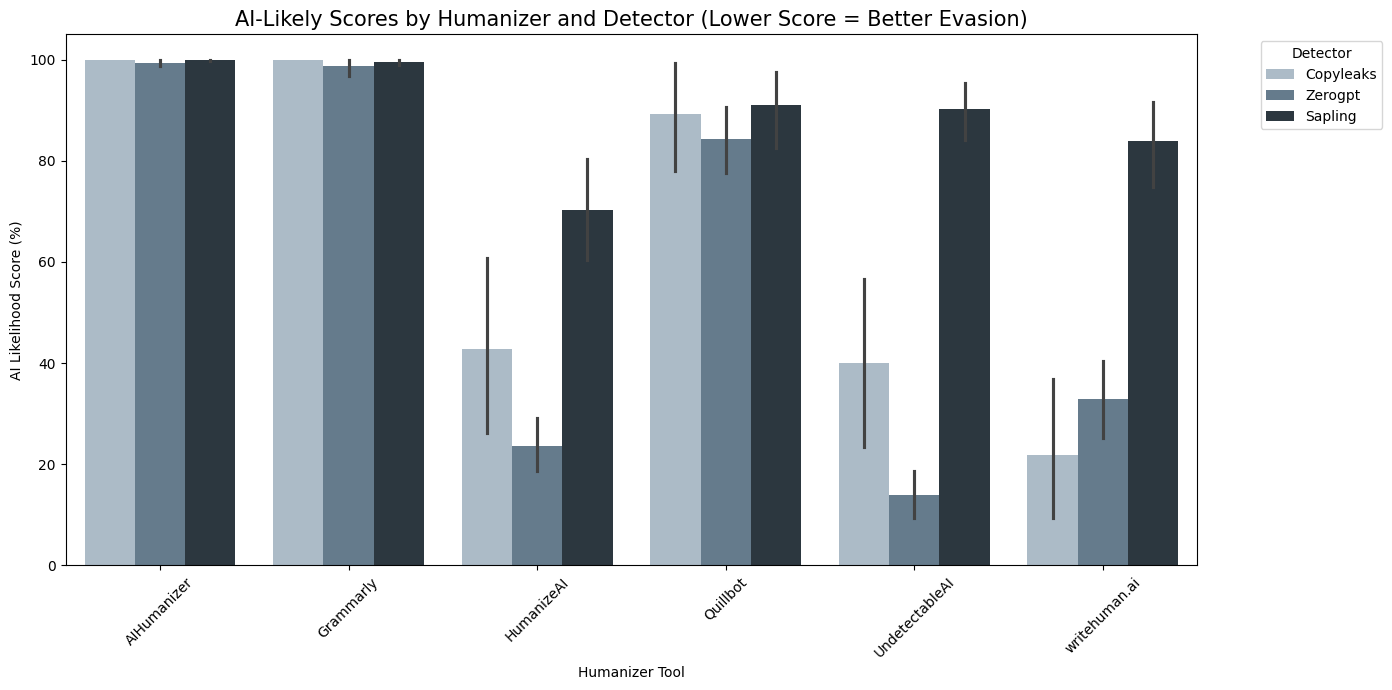

/var/folders/sl/36wj2dpn1fvgpr5ydrsxz8wm0000gn/T/ipykernel_99554/1835637972.py:17: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='AI_model', palette=custom_palette)


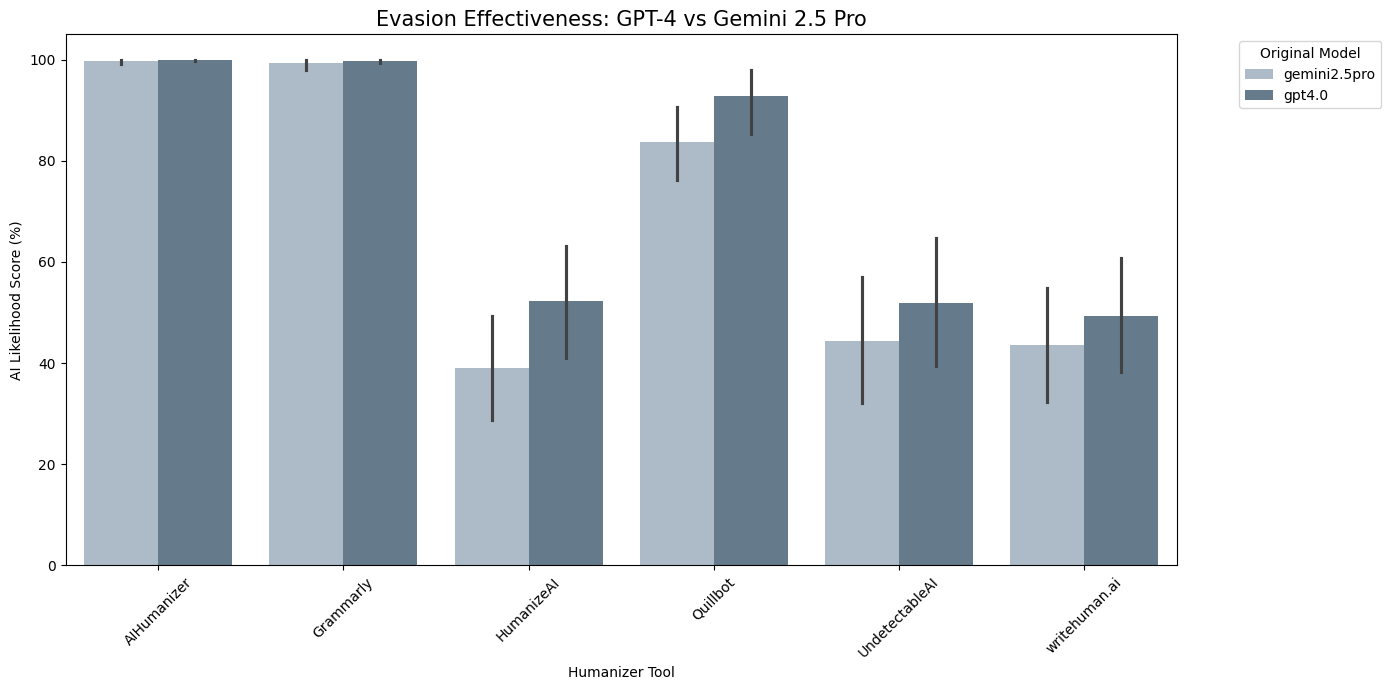

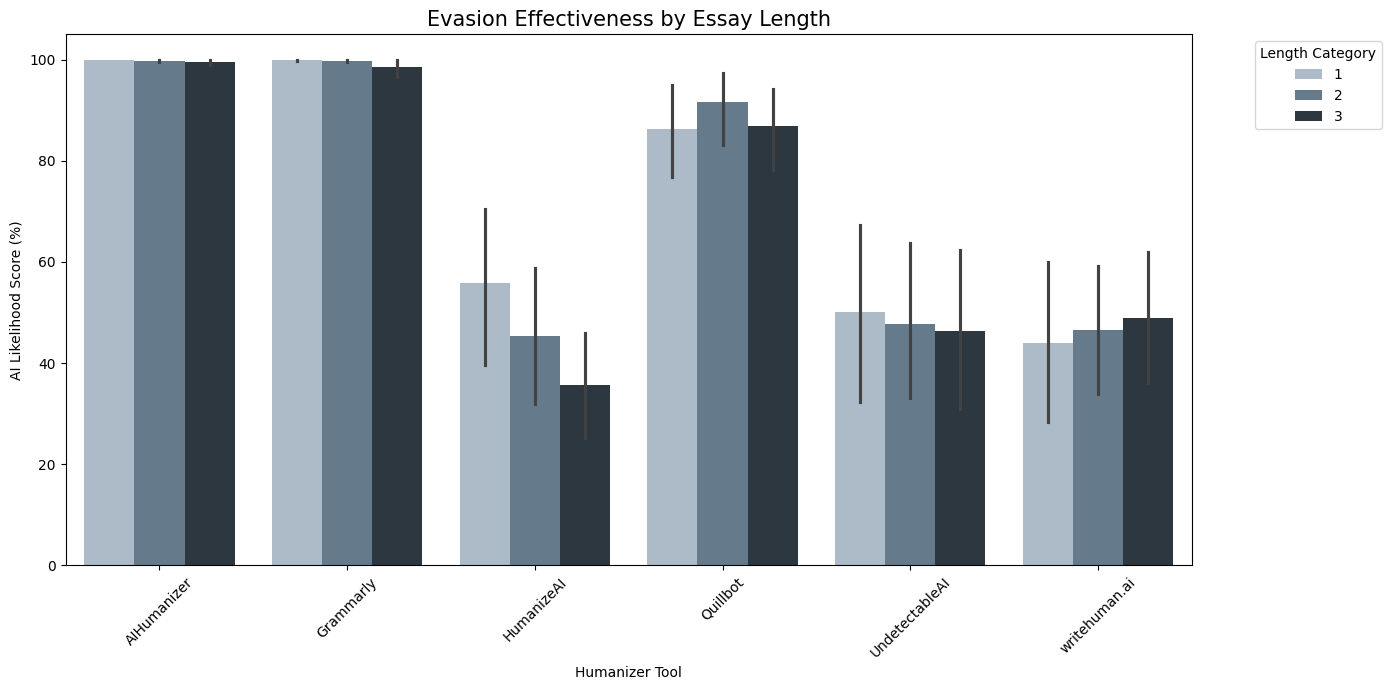

In [94]:
plt.rcParams['figure.figsize'] = (14, 7)

# --- Visualization 1: Performance across different Detectors ---
plt.figure()
sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='Detector', palette=custom_palette)
plt.title('AI-Likely Scores by Humanizer and Detector (Lower Score = Better Evasion)', fontsize=15)
plt.ylabel('AI Likelihood Score (%)')
plt.xlabel('Humanizer Tool')
plt.xticks(rotation=45)
plt.legend(title='Detector', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Visualization 2: Impact of the Original AI Model ---
# Does it matter if the essay was originally GPT or Gemini?
plt.figure()
sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='AI_model', palette=custom_palette)
plt.title('Evasion Effectiveness: GPT-4 vs Gemini 2.5 Pro', fontsize=15)
plt.ylabel('AI Likelihood Score (%)')
plt.xlabel('Humanizer Tool')
plt.xticks(rotation=45)
plt.legend(title='Original Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- Visualization 3: Impact of Essay Length ---
# Does length (1, 2, 3) affect detection?
plt.figure()
sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='length', palette=custom_palette)
plt.title('Evasion Effectiveness by Essay Length', fontsize=15)
plt.ylabel('AI Likelihood Score (%)')
plt.xlabel('Humanizer Tool')
plt.xticks(rotation=45)
plt.legend(title='Length Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()